# Teste em Tempo Real (Webcam) — LIBRAS YOLO

Notebook para testar o modelo treinado em **tempo real** usando a webcam.

## Pré-requisitos
- Rodar **localmente** (Colab não acessa webcam local diretamente)
- Ter o `best.pt` baixado do Colab e colocado em `models/best.pt` (ou ajustar o caminho)
- Webcam funcional (interna ou USB)

## Controles (na janela da webcam)
| Tecla | Ação |
|---|---|
| `Q` | Sair |
| `S` | Salvar snapshot anotado em `real_world_test/images/` |
| `+` / `-` | Aumentar / diminuir threshold de confiança |

---
## 1. Instalação

In [1]:
%pip install ultralytics opencv-python --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import time
from datetime import datetime
import cv2
from ultralytics import YOLO

print(f'OpenCV: {cv2.__version__}')

OpenCV: 4.13.0


---
## 2. Configuração

Ajuste o caminho do modelo treinado e o índice da webcam se precisar.

In [3]:
# Caminho do modelo treinado (best.pt baixado do Colab)
MODEL_PATH = 'models/best.pt'

# Pasta para salvar snapshots
SNAPSHOT_DIR = 'real_world_test/images'

# Índice da webcam (0 = padrão, 1 = segunda câmera, etc.)
CAMERA_INDEX = 0

# Resolução desejada (a webcam pode ajustar para a mais próxima suportada)
FRAME_WIDTH = 1280
FRAME_HEIGHT = 720

# Threshold inicial de confiança (0–1)
CONF_THRESHOLD = 0.35

# Imagem de input para o YOLO (tem que bater com imgsz do treino)
INFER_IMGSZ = 640

assert os.path.exists(MODEL_PATH), f'Modelo não encontrado em: {MODEL_PATH}'
os.makedirs(SNAPSHOT_DIR, exist_ok=True)
print(f'✅ Modelo: {MODEL_PATH}')
print(f'✅ Snapshots vão para: {SNAPSHOT_DIR}')

✅ Modelo: models/best.pt
✅ Snapshots vão para: real_world_test/images


In [4]:
# Carrega o modelo (apenas uma vez)
model = YOLO(MODEL_PATH)
print(f'Classes do modelo: {model.names}')

Classes do modelo: {0: 'A', 1: 'Ajuda', 2: 'B', 3: 'Banheiro', 4: 'C', 5: 'Cade', 6: 'Casa', 7: 'D', 8: 'E', 9: 'Em pe', 10: 'Eu', 11: 'F', 12: 'Febre', 13: 'G', 14: 'Gosto', 15: 'I', 16: 'L', 17: 'M', 18: 'N', 19: 'O', 20: 'P', 21: 'Policial', 22: 'Q', 23: 'R', 24: 'S', 25: 'T', 26: 'Te amo', 27: 'Telefone', 28: 'Tenho', 29: 'U', 30: 'V', 31: 'Vacina', 32: 'Voce', 33: 'W', 34: 'Y'}


---
## 3. (Opcional) Teste um único frame primeiro

Antes do loop contínuo, pega um frame para garantir que a câmera funciona e o modelo prediz corretamente.

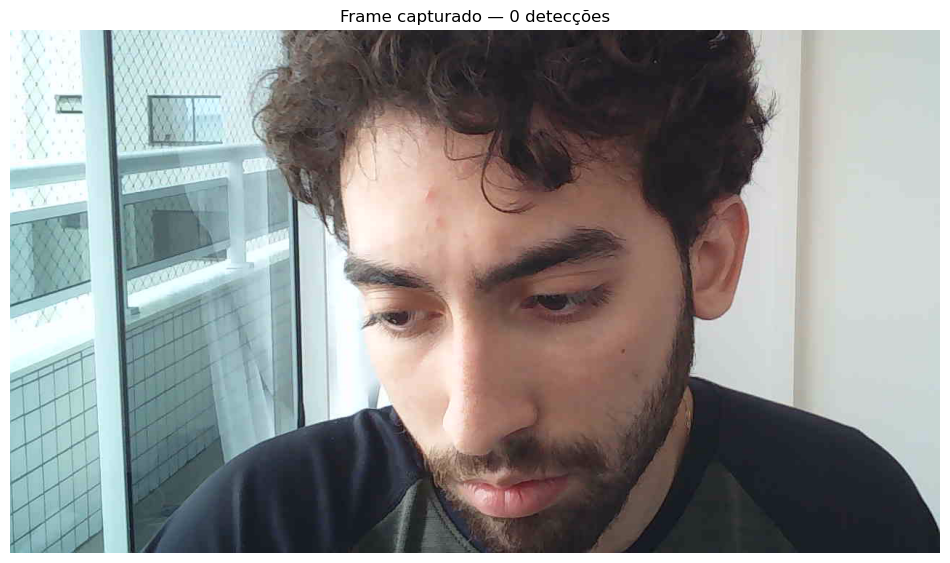

In [5]:
import matplotlib.pyplot as plt

# CAP_DSHOW é o backend mais estável no Windows
cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

if not cap.isOpened():
    raise RuntimeError(f'Não consegui abrir a câmera no índice {CAMERA_INDEX}. Tente outro índice.')

# Pega alguns frames (a webcam demora pra estabilizar exposição)
for _ in range(5):
    ret, frame = cap.read()

cap.release()

if not ret:
    raise RuntimeError('Não consegui capturar frame da câmera.')

# Inferência
result = model.predict(frame, conf=CONF_THRESHOLD, imgsz=INFER_IMGSZ, verbose=False)[0]
annotated = result.plot()

# Mostra no notebook (BGR -> RGB)
plt.figure(figsize=(12, 7))
plt.imshow(annotated[:, :, ::-1])
plt.axis('off')
plt.title(f'Frame capturado — {len(result.boxes)} detecções')
plt.show()

for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f'  {model.names[cls_id]:>3s}  conf={conf:.3f}')

---
## 4. Loop em Tempo Real

Abre uma janela do OpenCV com inferência contínua. Use `Q` para sair.

> ⚠️ Se a janela ficar congelada ou não responder ao `Q`, clique nela primeiro para focar e tente de novo. Em último caso, **interrompa o kernel** (botão de parar).

In [11]:
cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

if not cap.isOpened():
    raise RuntimeError(f'Não consegui abrir a câmera no índice {CAMERA_INDEX}.')

conf_atual = CONF_THRESHOLD
window_name = 'LIBRAS YOLO — Q: sair | S: snapshot | +/-: confianca'

# Buffer para média móvel de FPS
fps_buffer = []
buffer_size = 30

try:
    while True:
        t0 = time.time()
        ret, frame = cap.read()
        if not ret:
            print('Erro ao ler frame.')
            break

        # Inferência
        result = model.predict(frame, conf=conf_atual, imgsz=INFER_IMGSZ, verbose=False)[0]
        annotated = result.plot()

        # FPS
        dt = time.time() - t0
        fps_buffer.append(1.0 / max(dt, 1e-6))
        if len(fps_buffer) > buffer_size:
            fps_buffer.pop(0)
        fps = sum(fps_buffer) / len(fps_buffer)

        # Overlay de status (FPS + threshold + número de detecções)
        overlay = annotated.copy()
        cv2.rectangle(overlay, (5, 5), (380, 95), (0, 0, 0), -1)
        annotated = cv2.addWeighted(overlay, 0.6, annotated, 0.4, 0)
        cv2.putText(annotated, f'FPS: {fps:5.1f}', (15, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(annotated, f'Conf: {conf_atual:.2f}  Det: {len(result.boxes)}', (15, 75),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        cv2.imshow(window_name, annotated)

        # Captura de teclado
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:  # Q ou ESC
            break
        elif key == ord('s'):
            ts = datetime.now().strftime('%Y%m%d_%H%M%S')
            path = os.path.join(SNAPSHOT_DIR, f'snapshot_{ts}.jpg')
            cv2.imwrite(path, annotated)
            print(f'📸 Snapshot salvo: {path}')
        elif key in (ord('+'), ord('=')):
            conf_atual = min(0.95, conf_atual + 0.05)
            print(f'Confiança: {conf_atual:.2f}')
        elif key == ord('-'):
            conf_atual = max(0.05, conf_atual - 0.05)
            print(f'Confiança: {conf_atual:.2f}')
finally:
    cap.release()
    cv2.destroyAllWindows()
    # Workaround para janelas presas no Windows/Jupyter
    for _ in range(4):
        cv2.waitKey(1)
    print('🛑 Webcam liberada.')

📸 Snapshot salvo: real_world_test/images\snapshot_20260605_113230.jpg
📸 Snapshot salvo: real_world_test/images\snapshot_20260605_113255.jpg
📸 Snapshot salvo: real_world_test/images\snapshot_20260605_113307.jpg
🛑 Webcam liberada.


---
## 5. (Opcional) Listar câmeras disponíveis

Se a câmera padrão não funcionar, esta célula testa os primeiros índices para descobrir quais estão disponíveis.

In [7]:
for idx in range(4):
    cap_test = cv2.VideoCapture(idx, cv2.CAP_DSHOW)
    if cap_test.isOpened():
        ret, _ = cap_test.read()
        w = int(cap_test.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap_test.get(cv2.CAP_PROP_FRAME_HEIGHT))
        status = '✅ funciona' if ret else '⚠️  abre mas não captura'
        print(f'Câmera {idx}: {status}  ({w}x{h})')
        cap_test.release()
    else:
        print(f'Câmera {idx}: ❌ não disponível')

Câmera 0: ✅ funciona  (640x480)
Câmera 1: ❌ não disponível
Câmera 2: ❌ não disponível
Câmera 3: ❌ não disponível


---
## 6. (Opcional) Gravar vídeo com predições

Útil pra anexar no relatório técnico. Grava por N segundos e salva em `results/`.

In [8]:
DURACAO_SEGUNDOS = 10
OUTPUT_VIDEO = f'results/webcam_libras_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
os.makedirs('results', exist_ok=True)

cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 20.0, (w, h))

t_inicio = time.time()
n_frames = 0
print(f'🎥 Gravando {DURACAO_SEGUNDOS}s... (NÃO interrompa)')

try:
    while time.time() - t_inicio < DURACAO_SEGUNDOS:
        ret, frame = cap.read()
        if not ret:
            break
        result = model.predict(frame, conf=CONF_THRESHOLD, imgsz=INFER_IMGSZ, verbose=False)[0]
        annotated = result.plot()
        writer.write(annotated)
        cv2.imshow('Gravando...', annotated)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        n_frames += 1
finally:
    cap.release()
    writer.release()
    cv2.destroyAllWindows()
    for _ in range(4):
        cv2.waitKey(1)

print(f'✅ Vídeo salvo em: {OUTPUT_VIDEO}')
print(f'   {n_frames} frames em {time.time() - t_inicio:.1f}s')

🎥 Gravando 10s... (NÃO interrompa)
✅ Vídeo salvo em: results/webcam_libras_20260605_112646.mp4
   40 frames em 10.3s
